In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

In [44]:
# 2. CARGAR LOS DATOS

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

train.head()

Train: (110100, 25)
Test: (9900, 24)


,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,...,es_nuevo_cliente,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo
0,1,202601,26,42120.349663,0.367310,139,2,40949.765573,67,professional,...,False,False,222,10,9.898223,android,21,True,67,0
1,2,202601,56,89837.390440,0.338092,29,2,35233.622561,304,manager,...,False,False,58,2,9.311922,ios,20,True,304,0
2,3,202601,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,...,False,False,8,6,12.188249,android,12,False,220,0
3,4,202601,62,54673.148516,0.243261,43,2,300.000000,110,manual,...,False,False,119,9,10.459796,ios,20,False,110,0
4,5,202601,37,100239.135609,0.230946,113,1,32066.808006,247,professional,...,False,False,25,6,36.502645,ios,13,False,247,1


In [45]:
# 3. FEATURE ENGINEERING

def crear_features(df):
    df = df.copy()

    df["numero_mes"] = df["mes"] % 100

    df["actividad_digital"] = (
        df["visitas_web_ultimos_90_dias"] +
        df["activo_movil"].astype(int)
    )

    df["productos_por_antiguedad"] = (
        df["numero_productos"] /
        (df["antiguedad_cuenta_meses"] + 1)
    )

    df["recencia_promedio"] = (
        df["dias_ultima_transaccion"] +
        df["dias_ultima_interaccion"]
    ) / 2

    df["saldo_ingreso"] = (
        df["saldo_promedio"] /
        (df["ingresos"] + 1)
    )

    df["cantidad_productos_extra"] = (
        df["tiene_tarjeta_credito"].astype(int) +
        df["tiene_prestamo"].astype(int) +
        df["tiene_seguro"].astype(int)
    )

    return df

train = crear_features(train)
test = crear_features(test)

In [46]:
# VALIDACIÓN TEMPORAL
# Enero a octubre = entrenamiento
# Noviembre = validación

train_temporal = train[train["mes"] < 202611].copy()
val_temporal = train[train["mes"] == 202611].copy()

X_train = train_temporal.drop(columns=["objetivo", "id_cliente"])
y_train = train_temporal["objetivo"]

X_val = val_temporal.drop(columns=["objetivo", "id_cliente"])
y_val = val_temporal["objetivo"]

X_test = test.drop(columns=["id_cliente"])
test_ids = test["id_cliente"].copy()

print("Entrenamiento:", X_train.shape)
print("Validación noviembre:", X_val.shape)
print("Test:", X_test.shape)

Entrenamiento: (100600, 29)
Validación noviembre: (9500, 29)
Test: (9900, 29)


In [47]:
# 3. REVISAR INFORMACION BASICA

print(train.info())

print("\nValores nulos en train:")
print(train.isnull().sum())

print("\nDistribución del objetivo:")
print(train["objetivo"].value_counts())

print("\nProporción:")
print(train["objetivo"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110100 entries, 0 to 110099
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_cliente                   110100 non-null  int64  
 1   mes                          110100 non-null  int64  
 2   edad                         110100 non-null  int64  
 3   ingresos                     110100 non-null  float64
 4   ratio_deuda_ingresos         110100 non-null  float64
 5   antiguedad_cuenta_meses      110100 non-null  int64  
 6   numero_productos             110100 non-null  int64  
 7   saldo_promedio               110100 non-null  float64
 8   dias_ultima_transaccion      110100 non-null  int64  
 9   ocupacion                    110100 non-null  object 
 10  region                       110100 non-null  object 
 11  canal_adquisicion            110100 non-null  object 
 12  banda_riesgo                 110100 non-null  object 
 13 

In [48]:
# 4. Separar variables y objetivo
X = train.drop(columns=["objetivo"])
y = train["objetivo"]

print("X:", X.shape)
print("y:", y.shape)

X: (110100, 30)
y: (110100,)


In [49]:
# 5. Guardar el ID y quitarlo del entrenamiento

test_ids = test["id_cliente"].copy()

X = X.drop(columns=["id_cliente"])
X_test = test.drop(columns=["id_cliente"])

print(X.shape)
print(X_test.shape)

(110100, 29)
(9900, 29)


In [50]:
# 6. Definir variables categóricas

columnas_categoricas = [
    "ocupacion",
    "region",
    "canal_adquisicion",
    "banda_riesgo",
    "dispositivo_principal"
]

columnas_otros = [
    columna
    for columna in X.columns
    if columna not in columnas_categoricas
]

print("Variables categóricas:")
print(columnas_categoricas)

print("\nOtras variables:")
print(columnas_otros)

Variables categóricas:
['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']

Otras variables:
['mes', 'edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses', 'numero_productos', 'saldo_promedio', 'dias_ultima_transaccion', 'tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'antiguedad_direccion_meses', 'visitas_web_ultimos_90_dias', 'distancia_sucursal_km', 'dia_preferido_pago', 'tiene_seguro', 'dias_ultima_interaccion', 'numero_mes', 'actividad_digital', 'productos_por_antiguedad', 'recencia_promedio', 'saldo_ingreso', 'cantidad_productos_extra']


In [52]:
# 8. Preprocesamiento

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            columnas_categoricas
        )
    ],
    remainder="passthrough"
)

In [53]:
# 9. Crear Random Forest

modelo = RandomForestClassifier(
    n_estimators=600,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

In [54]:
# 10. Crear el pipeline

pipeline = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ]
)

In [55]:
# 11. ENTRENAR MODELO

pipeline.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [56]:
# 12. Obtener probabilidades de validación

pred_val = pipeline.predict_proba(X_val)[:, 1]

print(pred_val[:10])

[0.25725788 0.09811865 0.49788901 0.09810047 0.49114911 0.40452909
 0.52370194 0.21884414 0.37321953 0.30827351]


In [57]:
# 13. Calcular ROC AUC y Gini

auc = roc_auc_score(y_val, pred_val)
gini = 2 * auc - 1

print("ROC AUC:", round(auc, 6))
print("GINI:", round(gini, 6))

ROC AUC: 0.596034
GINI: 0.192069


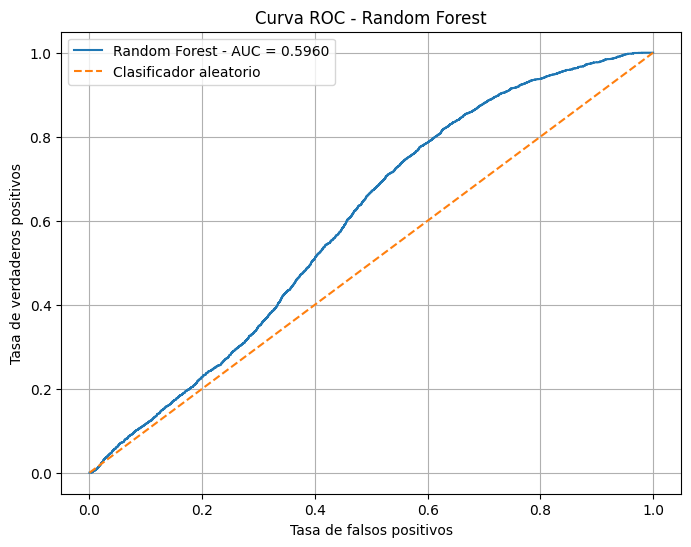

In [58]:
# 14. Curva ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_val)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest - AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title("Curva ROC - Random Forest")

plt.legend()
plt.grid()

plt.show()


In [59]:
#Importancia de las variables
modelo_entrenado = pipeline.named_steps["modelo"]
preprocesador_entrenado = pipeline.named_steps["preprocesamiento"]

nombres_variables = preprocesador_entrenado.get_feature_names_out()

importancias = modelo_entrenado.feature_importances_

importancia_df = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": importancias
})

importancia_df = importancia_df.sort_values(
    by="Importancia",
    ascending=False
).head(15)

importancia_df

,Variable,Importancia
43,remainder__recencia_promedio,0.057647
29,remainder__dias_ultima_transaccion,0.056283
39,remainder__dias_ultima_interaccion,0.053637
25,remainder__ratio_deuda_ingresos,0.052855
36,remainder__distancia_sucursal_km,0.050416
42,remainder__productos_por_antiguedad,0.050030
24,remainder__ingresos,0.050010
44,remainder__saldo_ingreso,0.048985
34,remainder__antiguedad_direccion_meses,0.047912
28,remainder__saldo_promedio,0.047199


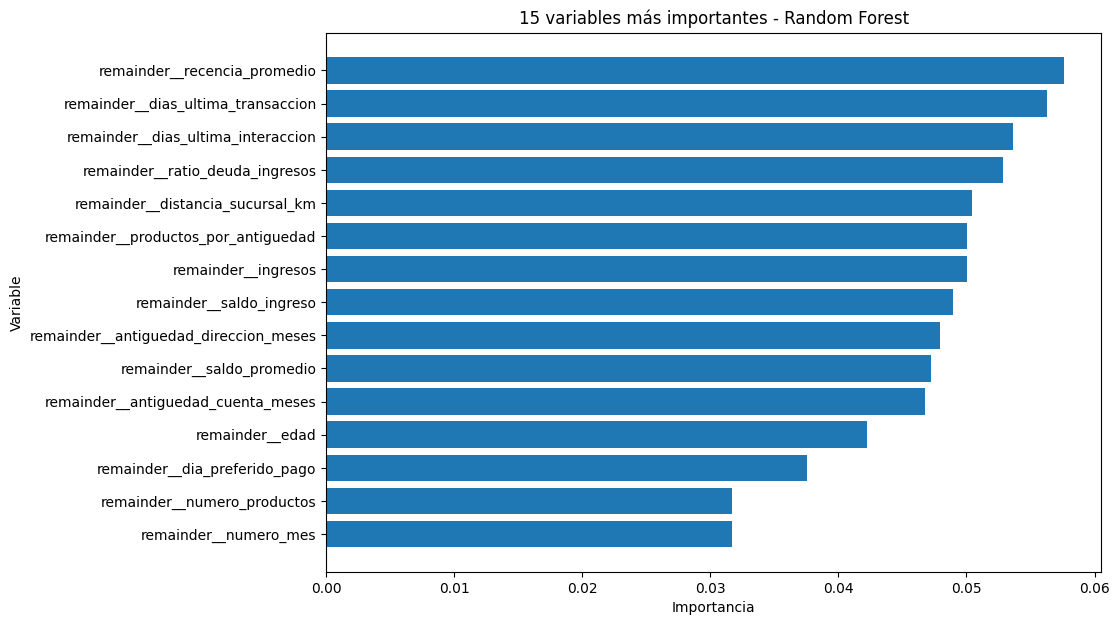

In [60]:
plt.figure(figsize=(10, 7))

plt.barh(
    importancia_df["Variable"],
    importancia_df["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.title(
    "15 variables más importantes - Random Forest"
)

plt.gca().invert_yaxis()

plt.show()

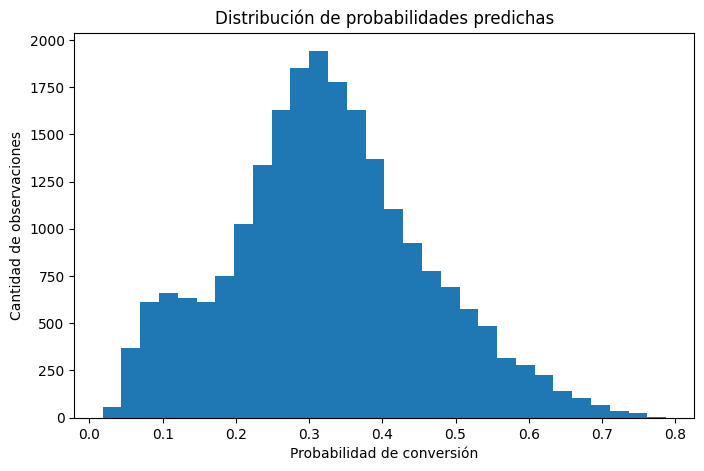

In [61]:
#Distribución de probabilidades
plt.figure(figsize=(8, 5))

plt.hist(
    pred_val,
    bins=30
)

plt.xlabel("Probabilidad de conversión")
plt.ylabel("Cantidad de observaciones")

plt.title(
    "Distribución de probabilidades predichas"
)

plt.show()

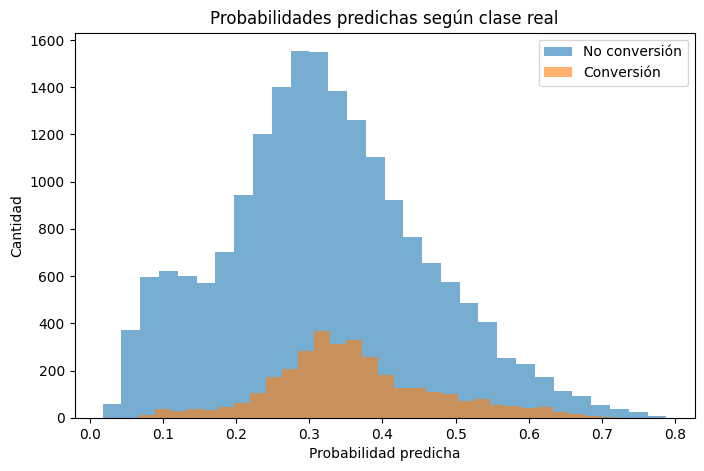

In [62]:
#Comparar probabilidades según la clase real
resultados_validacion = pd.DataFrame({
    "objetivo_real": y_val.values,
    "probabilidad": pred_val
})

plt.figure(figsize=(8, 5))

plt.hist(
    resultados_validacion[
        resultados_validacion["objetivo_real"] == 0
    ]["probabilidad"],
    bins=30,
    alpha=0.6,
    label="No conversión"
)

plt.hist(
    resultados_validacion[
        resultados_validacion["objetivo_real"] == 1
    ]["probabilidad"],
    bins=30,
    alpha=0.6,
    label="Conversión"
)

plt.xlabel("Probabilidad predicha")
plt.ylabel("Cantidad")

plt.title(
    "Probabilidades predichas según clase real"
)

plt.legend()

plt.show()

In [75]:
#Entrenar usando todo el train
# Entrenar
pipeline.fit(X_train, y_train)

# Predecir validación
pred_val = pipeline.predict_proba(X_val)[:, 1]

# Calcular AUC y Gini
auc = roc_auc_score(y_val, pred_val)
gini = 2 * auc - 1

print("ROC AUC:", auc)
print("GINI:", gini)

ROC AUC: 0.5960343770813906
GINI: 0.19206875416278124


In [81]:
X_final = train.drop(columns=["objetivo", "id_cliente"])
y_final = train["objetivo"]

In [82]:
# Entrenamiento final con todo el train
pipeline.fit(X_final, y_final)

# Predicción del test
pred_test = pipeline.predict_proba(X_test)[:, 1]

In [83]:
#Crear el archivo de entrega
submission = pd.DataFrame({
    "id_cliente": test_ids,
    "prediccion": pred_test
})

submission.head()

,id_cliente,prediccion
0,2,0.192915
1,3,0.134526
2,7,0.331035
3,10,0.108046
4,11,0.196120


In [84]:
#Comprobar el submission
print("Dimensiones:")
print(submission.shape)

print("\nValor mínimo:")
print(submission["prediccion"].min())

print("\nValor máximo:")
print(submission["prediccion"].max())

print("\nValores nulos:")
print(submission.isnull().sum())

submission.head(10)

Dimensiones:
(9900, 2)

Valor mínimo:
0.04624194280771221

Valor máximo:
0.6984229460627206

Valores nulos:
id_cliente    0
prediccion    0
dtype: int64


,id_cliente,prediccion
0,2,0.192915
1,3,0.134526
2,7,0.331035
3,10,0.108046
4,11,0.196120
5,12,0.060239
6,14,0.263954
7,16,0.301973
8,25,0.208636
9,32,0.244412


In [87]:
from datetime import datetime

nombre = "predicciones_Chihuan_" + datetime.now().strftime("%H%M%S") + ".csv"
ruta = r"D:\UNCP XIMENA\SEMESTRES\hackaton\\" + nombre

submission.to_csv(ruta, index=False)
print("Guardado en:", ruta)

Guardado en: D:\UNCP XIMENA\SEMESTRES\hackaton\\predicciones_Chihuan_185915.csv
